In [1]:
from pathlib import Path
from collections import defaultdict

import numpy as np
import scipy
import pandas as pd

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad

import torch

from popari.model import load_trained_model, Popari
from popari.wandb_util import load_popari_model_from_wandb
from popari import pl, pp, tl

In [2]:
pl.set_notebook_mode("publication")

In [3]:
data_directory = Path("/work/magroup/shahula/spatiotemporal_transcriptomics_integration/data/STARmapPlus/SCP1375/")
figure_directory = Path("/work/magroup/shahula/spatiotemporal_transcriptomics_integration/Popari/notebooks/starmapplus_figures/")
figure_directory.mkdir(exist_ok=True)

## Load existing STARmap PLUS runs

In [4]:
relative_path = Path("/work/magroup/shahula/spatiotemporal_transcriptomics_integration/mlflow_experiments/STARmap_plus_eight_replicate/")

run_id = "51619701000747ebae1bc16ce2fe8d8d"  # All genes; binning downsample rate 0.2.

## Load unsuperresolved model

In [ ]:
context = dict(device="cuda:0", dtype=torch.float64)
model = load_popari_model_from_wandb(
    run_id,
    artifact_stem=None,
    context=context,
)

In [ ]:
model.set_superresolution_lr(1e-1)
model.superresolve(n_epochs=10000, tol=1e-6, use_manual_gradients=False, update_spatial_affinities=False)

In [ ]:
model.set_superresolution_lr(1e-2)
model.superresolve(n_epochs=10000, tol=1e-6, use_manual_gradients=False, update_spatial_affinities=True)

In [ ]:
model.save_results(relative_path / "domain_segmentation_model")

## Alternatively, load already superresolved models

In [5]:
model = load_trained_model(relative_path / "domain_segmentation_model")

[2026/07/30 13:34:16]	 Reloading level 0
[2026/07/30 13:34:18]	 Initializing MetageneState
[2026/07/30 13:34:18]	 Initializing SpatialAffinityState
[2026/07/30 13:34:18]	 Initializing EmbeddingOptimizer
[2026/07/30 13:34:22]	 Initializing EmbeddingState
[2026/07/30 13:34:25]	 Reloading level 1
[2026/07/30 13:34:25]	 Initializing MetageneState
[2026/07/30 13:34:25]	 Initializing SpatialAffinityState
[2026/07/30 13:34:25]	 Initializing EmbeddingOptimizer
[2026/07/30 13:34:26]	 Initializing EmbeddingState


## Clustering to discover spatial domains

In [6]:
FINE_LEVEL = 0
COARSE_LEVEL = model.hierarchical_levels - 1
fine_adata = model.hierarchy[FINE_LEVEL].adata
coarse_adata = model.hierarchy[COARSE_LEVEL].adata

In [ ]:
from importlib import reload
import popari
reload(popari.analysis.clustering)
reload(popari.analysis)
from popari import tl

In [ ]:
tl.postprocess_embeddings(coarse_adata)
tl.cluster_domains(coarse_adata)

In [26]:
from importlib import reload
import popari
reload(popari.plotting.spatial)
reload(popari.plotting)
from popari import pl

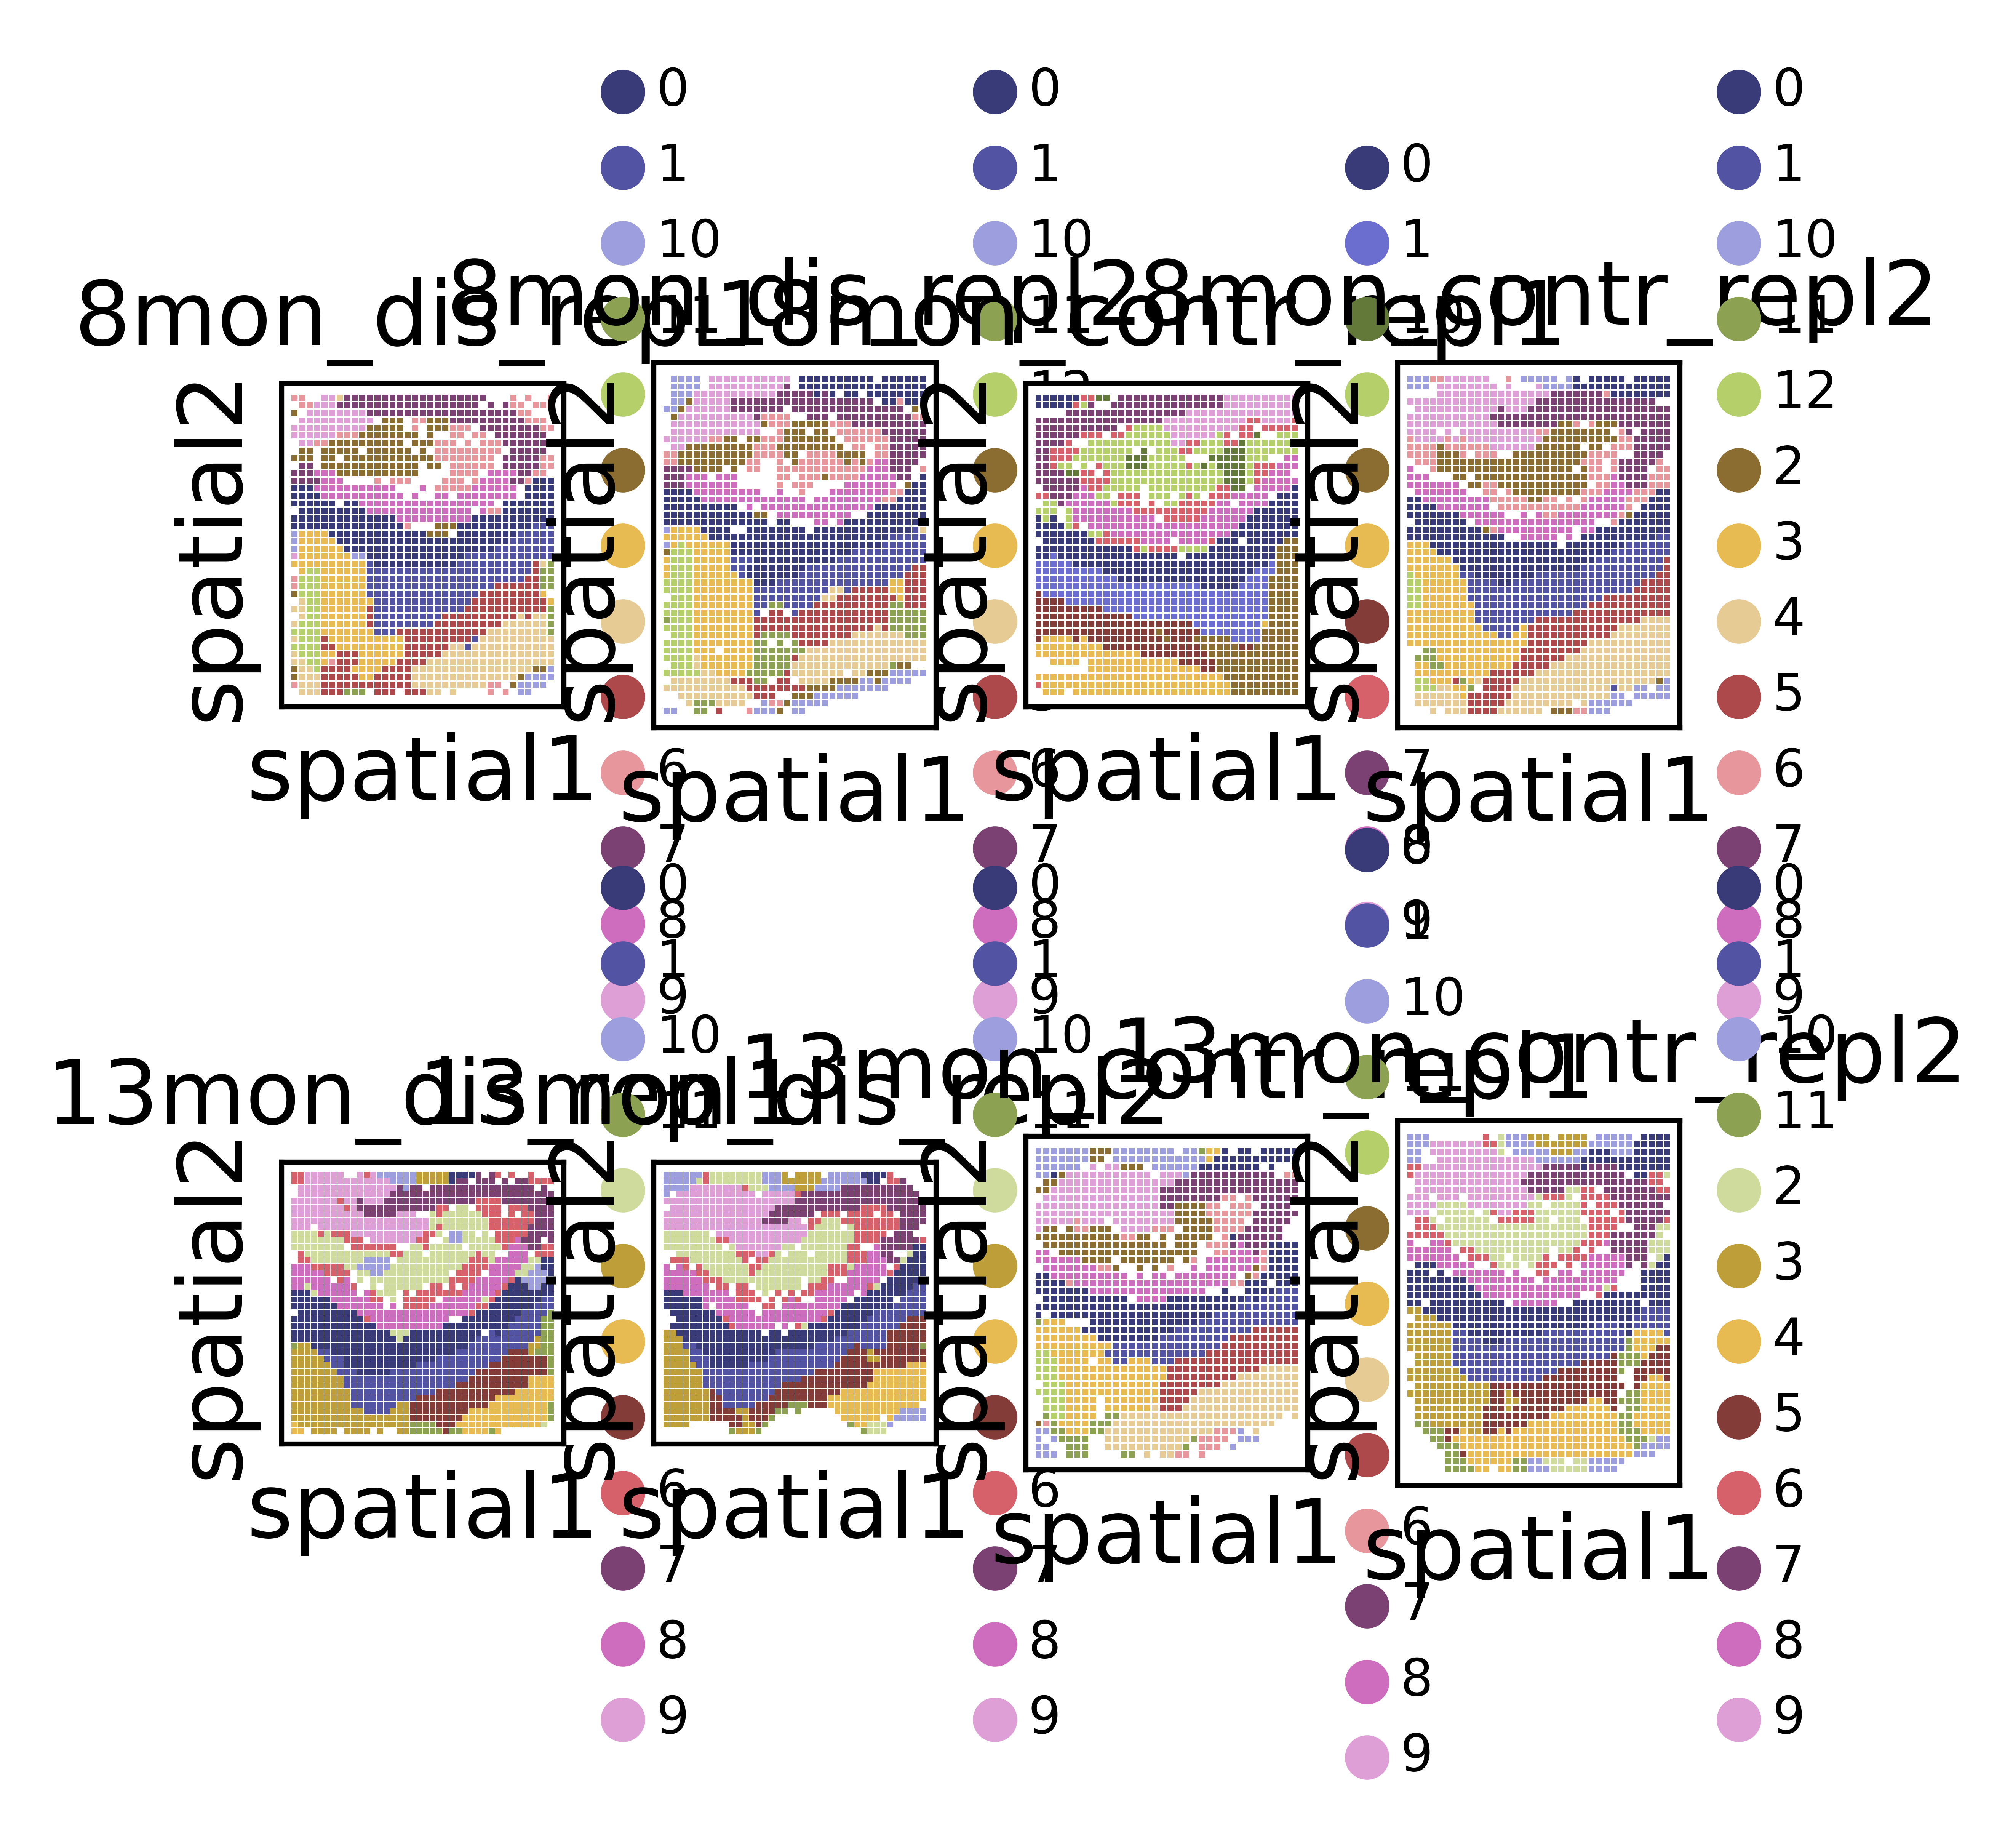

In [28]:
spatial_domain_fig = pl.in_situ(
    coarse_adata,
    edges_width=0,
    color="smoothed_domain",
    size=2,
    # figsize=(4, 2),
    dpi=600,
    marker=",",
    palette="tab20b",
)

In [ ]:
spatial_domain_fig.savefig(figure_directory/f"spatial_domain_fig.pdf", transparent=True)

In [11]:
tl.propagate_labels(
    {
        level: view.adata
        for level, view in enumerate(model.views)
    },
    "smoothed_domain",
    starting_level=COARSE_LEVEL,
)

In [24]:
spatial_domain_high_res_fig = pl.in_situ(
    fine_adata,
    edges_width=0,
    color="brain_domain",
    size=1,
    figsize=(8, 2),
    dpi=600,
    marker=",",
    palette="tab20b",
)

In [ ]:
spatial_domain_high_res_fig.savefig(figure_directory/f"spatial_domain_high_res_fig.pdf", transparent=True)

In [17]:
# Reload gene expressions.
from popari.io import load_anndata

raw_adata = load_anndata(data_directory / "eight_replicate_hvgs_None.h5ad")
fine_adata.X = raw_adata.X.copy()

In [14]:
label_mapping = {
    '11': 'L? (other excitatory) / 11',
    '0': 'WM / 0',
    '2': 'CAslmB / 2',
    '6': 'CAslmA / 6',
    '5': 'RSP B / 5',
    '3': 'L5 / 3',
    '12': 'RSP A / 12',
    '10': 'Meninges / 10',
    '4': 'L2/3/4 / 4',
    '1': 'L6 / 1',
    '8': 'CA1 / 8',
    '7': 'CA2/3 / 7',
    '9': 'DG / 9',
}

In [15]:
pp.relabel_categories(
    fine_adata,
    source="smoothed_domain",
    target="brain_domain",
    mapping=label_mapping,
)

In [20]:
ordering = ['Meninges / 10', 'L2/3/4 / 4', 'L5 / 3', 'L6 / 1', 'L? (other excitatory) / 11', 'RSP A / 12', 'RSP B / 5', 'WM / 0', 'CA1 / 8', 'CA2/3 / 7', 'DG / 9', 'CAslmA / 6', 'CAslmB / 2']

In [21]:
region_marker_scores = tl.compute_category_marker_scores(
    fine_adata,
    groupby="brain_domain",
    n_genes=10,
    categories=ordering,
)
region_marker_genes_fig = pl.category_marker_heatmap(
    region_marker_scores,
    dpi=600,
)

ValueError: categories must contain exactly the observed categories.

In [ ]:
region_marker_genes_fig.savefig(figure_directory / "region_marker_genes.pdf")

In [ ]:
cluster_correspondence_fig = pl.embedding_label_dotplot(
    coarse_adata,
    label_key="smoothed_domain",
    title="Metagene-to-Cluster Correspondence",
    swap_axes=False,
)

In [ ]:
cluster_correspondence_fig.savefig(figure_directory / "cluster_to_metagene_correspondence.pdf")

## Spatial affinity overview

In [ ]:
spatial_affinity_heatmap = pl.spatial_affinity_heatmap(
    coarse_adata,
    figsize=(12, 8),
    dpi=300,
)

## Attach cell-type annotations and pathology images

In [ ]:
from PIL import Image

corrected_image_directory = data_directory / "derived" / "orientation_corrected_images"

SAMPLE_FILES = {
    "8mon_dis_repl1": {
        "cell_types": data_directory / "cluster" / "spatial_8months-disease-replicate_1.csv",
        "plaque_metadata": data_directory / "other" / "plaque_8months-disease-replicate_1.csv",
    },
    "8mon_dis_repl2": {
        "cell_types": data_directory / "cluster" / "spatial_8months-disease-replicate_2.csv",
        "plaque_metadata": data_directory / "other" / "plaque_8months-disease-replicate_2.csv",
    },
    "8mon_contr_repl1": {
        "cell_types": data_directory / "cluster" / "spatial_8months-control-replicate_1.csv",
    },
    "8mon_contr_repl2": {
        "cell_types": data_directory / "cluster" / "spatial_8months-control-replicate_2.csv",
    },
    "13mon_dis_repl1": {
        "cell_types": data_directory / "cluster" / "spatial_13months-disease-replicate_1.csv",
        "plaque_metadata": data_directory / "other" / "plaque_13months-disease-replicate_1.csv",
    },
    "13mon_dis_repl2": {
        "cell_types": data_directory / "cluster" / "spatial_13months-disease-replicate_2.csv",
        "plaque_metadata": data_directory / "other" / "plaque_13months-disease-replicate_2.csv",
    },
    "13mon_contr_repl1": {
        "cell_types": data_directory / "cluster" / "spatial_13months-control-replicate_1.csv",
    },
    "13mon_contr_repl2": {
        "cell_types": data_directory / "cluster" / "spatial_13months-control-replicate_2.csv",
    },
}

SPOT_DIAMETER_BY_LEVEL = {0: 20, 1: 150, 2: 200}
image_cache = {}


def _load_cell_types(adata, sample, filepath):
    annotations = pd.read_csv(filepath, header=0, skiprows=lambda row: row == 1)
    indices = adata.popari.sample_indices(sample)
    if len(annotations) != len(indices):
        raise ValueError(
            f"{sample}: expected {len(indices)} annotations, "
            f"found {len(annotations)}."
        )
    obs_names = adata.obs_names[indices]
    for key in ("sub_level_cell_type", "top_level_cell_type"):
        if key not in adata.obs:
            adata.obs[key] = pd.Series(index=adata.obs_names, dtype=object)
        adata.obs.loc[obs_names, key] = annotations[key].to_numpy()


def _load_corrected_image(filepath):
    if filepath not in image_cache:
        if not filepath.is_file():
            raise FileNotFoundError(
                f"Corrected image does not exist: {filepath}. "
                "Run copy_starmapplus_preprocessing.ipynb first."
            )
        with Image.open(filepath) as image:
            image_array = np.asarray(image).copy()
        if image_array.ndim == 2:
            image_array = np.repeat(image_array[..., None], 3, axis=-1)
        elif image_array.ndim != 3:
            raise ValueError(f"Unsupported image shape {image_array.shape}: {filepath}")
        image_cache[filepath] = image_array
    return image_cache[filepath]


def _attach_image(
    adata,
    sample,
    image_key,
    filepath,
    spot_diameter,
    scalef=0.99,
):
    library = adata.uns.setdefault("spatial", {}).setdefault(sample, {})
    library.setdefault("images", {})[image_key] = _load_corrected_image(filepath)
    scalefactors = library.setdefault("scalefactors", {})
    scalefactors[f"tissue_{image_key}_scalef"] = scalef
    scalefactors["spot_diameter_fullres"] = spot_diameter


for level, view in enumerate(model.views):
    if level not in SPOT_DIAMETER_BY_LEVEL:
        raise KeyError(f"No spot diameter configured for hierarchy level {level}.")
    adata = view.adata
    adata.uns.setdefault("plaque_data", {})
    for sample in adata.popari.sample_names:
        sample_files = SAMPLE_FILES[sample]

        if level == FINE_LEVEL:
            _load_cell_types(adata, sample, sample_files["cell_types"])

        if "plaque_metadata" not in sample_files:
            continue

        adata.uns["plaque_data"][sample] = pd.read_csv(
            sample_files["plaque_metadata"],
            header=0,
            skiprows=lambda row: row == 1,
        )
        for image_key in ("plaque_contrast_adjusted", "tau_contrast_adjusted"):
            image_path = corrected_image_directory / f"{sample}_{image_key}.tif"
            _attach_image(
                adata,
                sample,
                image_key,
                image_path,
                spot_diameter=SPOT_DIAMETER_BY_LEVEL[level],
            )

for key in ("sub_level_cell_type", "top_level_cell_type"):
    fine_adata.obs[key] = pd.Categorical(fine_adata.obs[key])

In [ ]:
disease_samples = tuple(
    sample
    for sample in fine_adata.popari.sample_names
    if "_dis_" in sample
)

## Combined datasets

In [ ]:
combined_datasets = {
    level: view.adata
    for level, view in enumerate(model.views)
}
merged_dataset = combined_datasets[FINE_LEVEL]

## UMAP of all cells

In [ ]:
tl.postprocess_embeddings(merged_dataset, input_key="X", mode="joint")

In [ ]:
sc.tl.umap(merged_dataset, random_state=0, min_dist=0.05)

In [ ]:
from matplotlib import colors
def categorical_cmap(nc, nsc, ccolors=None, cmap="tab20", continuous=False):
    if not ccolors:
        if nc > plt.get_cmap(cmap).N:
            raise ValueError("Too many categories for colormap.")
        if continuous:
            ccolors = plt.get_cmap(cmap)(np.linspace(0,1,nc))
        else:
            ccolors = plt.get_cmap(cmap)(np.arange(nc, dtype=int))
    else:
        ccolors = [colors.to_rgb(color) for color in ccolors][:nc]

        
    cols = np.zeros((nc*nsc, 3))
    for i, c in enumerate(ccolors):
        chsv = colors.rgb_to_hsv(c[:3])
        arhsv = np.tile(chsv,nsc).reshape(nsc, 3)
        arhsv[:, 1] = np.linspace(chsv[1], 0.25, nsc)
        arhsv[:, 2] = np.linspace(chsv[2], 1, nsc)
        rgb = colors.hsv_to_rgb(arhsv)
        cols[i*nsc:(i+1)*nsc,:] = rgb       
    cmap = colors.ListedColormap(cols)
    return cmap

In [ ]:
top_level_colors = sc.pl.palettes.default_20 

# Extract the list of colors from your custom batch cycler
# (Assuming batch_cmap.colors is a list, or extracting from a cycler)
batch_cmap = categorical_cmap(4, 2, ccolors=["red", "orange", "green", "blue"])
batch_colors = [c['color'] for c in plt.cycler('color', batch_cmap.colors)]

# 2. Inject the color lists directly into the dataset's .uns dictionary
# Scanpy looks for the specific naming convention: "{obs_column}_colors"
merged_dataset.uns["top_level_cell_type_colors"] = top_level_colors
merged_dataset.uns["batch_colors"] = batch_colors

# 3. Plot both variables simultaneously with their distinct palettes
overall_umap_fig = sc.pl.umap(merged_dataset, color=["smoothed_domain", "top_level_cell_type", "batch"], return_fig=True)

In [ ]:
overall_umap_fig.savefig(figure_directory / "overall_umap_fig.pdf", transparent=True)

## Cohort subsets

In [ ]:
prefixes = ("8mon_contr", "8mon_dis", "13mon_contr", "13mon_dis")
cohort_datasets = {}
sample_groups_by_level = {}

for level, combined_dataset in combined_datasets.items():
    sample_groups = {
        prefix: [
            sample
            for sample in combined_dataset.popari.sample_names
            if sample.startswith(prefix)
        ]
        for prefix in prefixes
    }
    sample_groups_by_level[level] = sample_groups
    cohort_datasets[level] = pp.subset_samples(
        combined_dataset,
        sample_groups,
    )
    average_affinities = tl.aggregate_sample_matrices(
        combined_dataset,
        sample_groups,
        key="Sigma_x_inv",
    )
    combined_dataset.uns["average_Sigma_x_inv"] = average_affinities
    for cohort_dataset in cohort_datasets[level].values():
        cohort_dataset.uns["average_Sigma_x_inv"] = average_affinities

## Cell type correspondence

In [ ]:
cell_type_correspondence_fig = pl.embedding_label_dotplot(merged_dataset, embedding_key="normalized_X", label_key="top_level_cell_type", title="Cell Type-to-Cluster Correspondence", swap_axes=False)

In [ ]:
cell_type_correspondence_fig.savefig(figure_directory / "cell_type_correspondence.pdf", transparent=True)

## Spatial affinity difference matrices

In [ ]:
contr_vs_dis_8mon_affinity_magnitude_fig = pl.affinity_difference(
    combined_datasets[COARSE_LEVEL],
    comparison="8mon_dis",
    reference="8mon_contr",
    spatial_affinity_key="average_Sigma_x_inv",
    figsize=(4, 4),
    dpi=300,
    cell_grid=True,
    cell_grid_color="gray",
    cell_grid_width=0.2,
)

In [ ]:
contr_vs_dis_13mon_affinity_magnitude_fig = pl.affinity_difference(
    combined_datasets[COARSE_LEVEL],
    comparison="13mon_dis",
    reference="13mon_contr",
    spatial_affinity_key="average_Sigma_x_inv",
    figsize=(4, 4),
    dpi=300,
    cell_grid=True,
    cell_grid_color="gray",
    cell_grid_width=0.2,
)

In [ ]:
contr_8mon_vs_13mon_affinity_magnitude_fig = pl.affinity_difference(
    combined_datasets[COARSE_LEVEL],
    comparison="13mon_contr",
    reference="8mon_contr",
    spatial_affinity_key="average_Sigma_x_inv",
    figsize=(4, 4),
    dpi=300,
    cell_grid=True,
    cell_grid_color="gray",
    cell_grid_width=0.2,
)

In [ ]:
dis_8mon_vs_13mon_affinity_magnitude_fig = pl.affinity_difference(
    combined_datasets[COARSE_LEVEL],
    comparison="13mon_dis",
    reference="8mon_dis",
    spatial_affinity_key="average_Sigma_x_inv",
    figsize=(4, 4),
    dpi=300,
)

In [ ]:
contr_vs_dis_8mon_affinity_magnitude_fig.savefig(figure_directory / "contr_vs_dis_8mon_affinity_magnitude_fig.pdf", transparent=True)
contr_vs_dis_13mon_affinity_magnitude_fig.savefig(figure_directory / "contr_vs_dis_13mon_affinity_magnitude_fig.pdf", transparent=True)
contr_8mon_vs_13mon_affinity_magnitude_fig.savefig(figure_directory / "contr_8mon_vs_13mon_affinity_magnitude_fig.pdf", transparent=True)
dis_8mon_vs_13mon_affinity_magnitude_fig.savefig(figure_directory / "dis_8mon_vs_13mon_affinity_magnitude_fig.pdf", transparent=True)

## In-situ protein marker figs (skip if low-memory)

In [ ]:
from scipy.spatial import distance_matrix


def _compute_plaque_distances(dataset, plaque_data):
    '''Compute each observation's distance to its nearest plaque.'''

    cell_coordinates = dataset.obsm["spatial"]
    plaque_coordinates = plaque_data[["m.cx", "m.cy"]]
    plaque_radii = plaque_data["s.radius.mean"].to_numpy()

    distances = distance_matrix(cell_coordinates, plaque_coordinates)
    distances = np.abs(distances - plaque_radii[np.newaxis, :])
    return distances, distances.min(axis=1)

In [ ]:
IMAGE_KEYS = ("tau_contrast_adjusted", "plaque_contrast_adjusted")
coarse_adata.uns.setdefault("distances_to_plaques", {})

for sample in disease_samples:
    indices = coarse_adata.popari.sample_indices(sample)
    sample_dataset = coarse_adata[indices].copy()
    plaque_data = coarse_adata.uns["plaque_data"][sample]
    distances, minimum_distances = _compute_plaque_distances(
        sample_dataset,
        plaque_data,
    )
    coarse_adata.uns["distances_to_plaques"][sample] = distances
    coarse_adata.obs.loc[
        sample_dataset.obs_names,
        "min_distance_to_plaque",
    ] = minimum_distances

    for image_key in IMAGE_KEYS:
        image_feature_key = f"{image_key}_summary_features"
        image = sq.im.ImageContainer.from_adata(
            sample_dataset,
            img_key=image_key,
            library_id=sample,
        )
        sq.im.calculate_image_features(
            sample_dataset,
            image,
            library_id=sample,
            features="summary",
            spot_scale=10,
            key_added=image_feature_key,
        )
        sample_features = sample_dataset.obsm[image_feature_key]
        if image_feature_key not in coarse_adata.obsm:
            coarse_adata.obsm[image_feature_key] = pd.DataFrame(
                np.nan,
                index=coarse_adata.obs_names,
                columns=sample_features.columns,
            )
        coarse_adata.obsm[image_feature_key].loc[
            sample_dataset.obs_names,
            sample_features.columns,
        ] = sample_features.to_numpy()

In [ ]:
# Confirm that feature extraction is working well.
img_key = "tau_contrast_adjusted"
for sample in disease_samples:
    dataset = coarse_adata[coarse_adata.popari.sample_indices(sample)].copy()
    image_feature_key = f"{img_key}_summary_features"
    plot_dataset = sq.pl.extract(dataset, [image_feature_key, "X"])
    fig, axes = pl.setup_squarish_axes(4, dpi=100)
    sq.pl.spatial_scatter(
        plot_dataset,
        color=[None, "summary_ch-0_mean", "2", "9"],
        ax=axes.flat,
        fig=fig,
        size=8,
        shape="square",
        img_res_key=img_key,
        library_id=sample,
    )
    fig.savefig(
        figure_directory / f"tau_in_situ_correspondence_{sample}.pdf",
        transparent=True,
    )
    print(f"Finished {sample}")

In [ ]:
# Confirm that feature extraction is working well.
img_key = "plaque_contrast_adjusted"
for sample in disease_samples:
    dataset = coarse_adata[coarse_adata.popari.sample_indices(sample)].copy()
    image_feature_key = f"{img_key}_summary_features"
    plot_dataset = sq.pl.extract(dataset, [image_feature_key, "X"])
    fig, axes = pl.setup_squarish_axes(7, dpi=600)
    sq.pl.spatial_scatter(
        plot_dataset,
        color=[
            None,
            "summary_ch-0_mean",
            "min_distance_to_plaque",
            "0",
            "1",
            "7",
            "14",
        ],
        ax=axes.flat[:7],
        fig=fig,
        size=8,
        shape="square",
        img_res_key=img_key,
        library_id=sample,
    )
    fig.savefig(
        figure_directory / f"plaque_in_situ_correspondence_{sample}.pdf",
        transparent=True,
    )
    print(f"Finished {sample}")

## Plot metagene signature across replicates

In [ ]:
CELL_TYPE_KEY = "top_level_cell_type"
REGION_KEY = "brain_domain"

unique_cell_types = ("Micro", "Oligo", "Astro")
unique_regions = sorted(fine_adata.obs[REGION_KEY].dropna().unique())
DISEASE_CONTROL_COMPARISONS = {
    "8 months": ("8mon_dis", "8mon_contr"),
    "13 months": ("13mon_dis", "13mon_contr"),
}
DEG_COMPARISONS = {
    **DISEASE_CONTROL_COMPARISONS,
    "13 vs 8 months disease": ("13mon_dis", "8mon_dis"),
}
gene_names = fine_adata.var_names

In [ ]:
metagene_2_signature_scores = pd.concat(
    {
        label: tl.compute_metagene_signature_expression(
            cohort_datasets[FINE_LEVEL][comparison],
            2,
            reference_dataset=cohort_datasets[FINE_LEVEL][reference],
            categories=unique_cell_types,
            category_key=CELL_TYPE_KEY,
            sensitivity=0.5,
        )
        for label, (comparison, reference) in DISEASE_CONTROL_COMPARISONS.items()
    },
    axis="columns",
    names=["comparison", "category"],
)
metagene_2_signature = metagene_2_signature_scores.index.to_list()
metagene_2_signature_fig = pl.matrix_heatmap(
    metagene_2_signature_scores,
    cmap="bwr",
    center_zero=True,
    dpi=600,
    figsize=(2, 8),
)

In [ ]:
metagene_2_signature_fig.savefig(figure_directory / "metagene_2_signature.pdf", transparent=True)

In [ ]:
metagene_7_signature_scores = pd.concat(
    {
        label: tl.compute_metagene_signature_expression(
            cohort_datasets[FINE_LEVEL][comparison],
            7,
            reference_dataset=cohort_datasets[FINE_LEVEL][reference],
            categories=unique_cell_types,
            category_key=CELL_TYPE_KEY,
            sensitivity=0.1,
        )
        for label, (comparison, reference) in DISEASE_CONTROL_COMPARISONS.items()
    },
    axis="columns",
    names=["comparison", "category"],
)
metagene_7_signature = metagene_7_signature_scores.index.to_list()
metagene_7_signature_fig = pl.matrix_heatmap(
    metagene_7_signature_scores,
    cmap="bwr",
    center_zero=True,
    dpi=600,
    figsize=(2, 8),
)

In [ ]:
metagene_7_signature_fig.savefig(figure_directory / "metagene_7_signature.pdf", transparent=True)

## Metagene overlap with known gene modules

In [ ]:
module_table = pd.read_csv(
    "/work/magroup/shahula/spatiotemporal_transcriptomics_integration/data/STARmapPlus/starmapplus_modules.csv",
    skiprows=4,
    header=None,
    usecols=[0, 1, 3, 4],
    names=["micro_gene", "micro_module", "astro_gene", "astro_module"],
)

daa_genes = set(module_table.loc[module_table["astro_module"] == "AM3", "astro_gene"].dropna())
dam_genes = set(module_table.loc[module_table["micro_module"] == "MM3", "micro_gene"].dropna())

In [ ]:
# From figure 7b, 7c in https://www.nature.com/articles/s41593-022-01251-x/figures/7
pig_module_8mon = [
    'Gfap',
    'Ank',
    'H2-k1',
    'Tgbfr2',
    'Selplg',
    'P2ry12',
    'C1gb',
    'Sparc',
    'Serpine2',
    'Ftl1',
    'Ctsb',
    'Cd68',
    'Myo9a',
    'Ly86',
    'Apoe',
    'Grn',
    'Ccl6',
    'Ctss',
    'Cd9',
    'Hexb',
    'Ctsl',
    'Itgb5',
    'Cst7',
    'C1qa',
    'Trem2',
    'Fcrls',
    'Cst3',
    'Lyz2',
    'Tmsb4x',
    'Axl',
    'Lamp1',
    'Tmem176b',
    'Cd63',
    'Tshz2',
    'Pfkp',
    'Astn2',
    'Cplx1',
    'Nap1l5',
    'Snap25',
    'Pak1',
    'Tox',
    'Aldoc',
    'Pcsk1n',
    'Vsnl1',
    'Gabra1',
    'Satb1',
    'Shank1',
    'Resp18',
    'Ckb',
]

pig_module_13mon = [
    'Lamp1',
    'Ccl4',
    'Sparc',
    'H2-ab1',
    'Mertk',
    'Tns3',
    'Ftl1',
    'Cd63',
    'Lyz2',
    'Hexb',
    'Ctss',
    'Ly86',
    'Ccl6',
    'Itgb5',
    'Ctsl',
    'Fcrls',
    'Ptpro',
    'Cst3',
    'Trem2',
    'C1qa',
    'C1qb',
    'Cst7',
    'Cd68',
    'Grn',
    'Cd9',
    'Ctsb',
    'Serpine2',
    'Myo9a',
    'Olfml3',
    'Ank',
    'Lyn',
    'Tgfbr2',
    'Сd83',
    'Gpnmb',
    'Apoe',
    'Кcnj2',
    'Fabp5',
    'Ifi27l2a',
    'Tpt1',
    'Fcgr1',
    'Nrp1',
    'Tmsb4x',
    'Kctd12',
    'Selplg',
    'P2ry12',
    'Pabpc1',
    'Plekho1',
    'Gpsm3',
    'Lilrb4a',
    'Fam2Oc',
    'Ctps',
    'Ly6e',
    'Axl',
    'H2-k1',
    'Anxa5',
    'Tmem176b',
    'Gfap',
    'Cd81',
    'Serpinb1b',
    'Itpr1',
    'Vim',
    'Mt1',
    'Mt2',
    'Slc9a3r2',
    'Fxyd1',
    'Tmsb10',
    'Aldoc',
    'Olfm2',
    'Epas1',
    'Tshz2',
    'Satb1',
    'Clu',
    'Tspan2',
    'Plp1',
    'Car2',
]

In [ ]:
dataset = fine_adata
metagenes = dataset.popari.metagenes
metagene_indices = {"m2": 2, "m7": 7}

metagene_signatures = {
    name: set(
        tl.get_metagene_signature(
            metagenes[:, index],
            dataset.var_names,
            sensitivity=0.5,
            type="upregulated",
            show_plot=False,
        )
    )
    for name, index in metagene_indices.items()
}
comparison_modules = {
    "m2": {
        "DAA": daa_genes,
        "DAM": dam_genes,
    },
    "m7": {
        "PIG 8 months": set(pig_module_8mon),
        "PIG 13 months": set(pig_module_13mon),
    },
}

gene_set_enrichment_results = pd.concat(
    [
        tl.compute_gene_set_enrichment(
            {metagene_name: metagene_signatures[metagene_name]},
            modules,
            background=dataset.var_names,
        )
        for metagene_name, modules in comparison_modules.items()
    ],
    ignore_index=True,
).sort_values(["query", "adjusted_pvalue", "reference"])

gene_set_enrichment_results

In [ ]:
gene_overlap_subdirectory = figure_directory / "gene_set_overlaps"
gene_overlap_subdirectory.mkdir(exist_ok=True)

for metagene_name, modules in comparison_modules.items():
    overlap_fig = pl.gene_set_upset(
        {metagene_name: metagene_signatures[metagene_name], **modules},
        background=dataset.var_names,
        dpi=200,
    )
    overlap_fig.savefig(
        gene_overlap_subdirectory / f"{metagene_name}_upset.pdf",
        transparent=True,
    )

### Cell-cell spatial accordance scores

In [ ]:
INTERACTION_CATEGORY_KEY = "top_level_cell_type"
INTERACTION_PAIRS = (
    ("Oligo", "Oligo"),
    ("Oligo", "Astro"),
    ("Micro", "Micro"),
    ("Oligo", "CTX-Ex"),
    ("LHb", "Inh"),
)

if fine_adata.popari.sample_names != coarse_adata.popari.sample_names:
    raise ValueError("Fine and coarse hierarchy levels must contain the same samples.")

edge_interactions = {
    sample: tl.compute_edge_interactions(
        fine_adata,
        sample=sample,
        affinity=coarse_adata.popari.spatial_affinity_for(sample),
    )
    for sample in fine_adata.popari.sample_names
}

In [ ]:
interaction_figures = {
    category_pair: pl.edge_interactions_panel(
        fine_adata,
        edge_interactions,
        category_key=INTERACTION_CATEGORY_KEY,
        category_pair=category_pair,
        directed=False,
        color=None,
        size=0,
        edge_cmap="seismic",
        dpi=600,
        figsize=(16, 8),
    )
    for category_pair in INTERACTION_PAIRS
}

In [ ]:
INTERACTION_FIGURE_FILENAMES = {
    ("Oligo", "Oligo"): "oligo_oligo_in_situ.pdf",
    ("Oligo", "Astro"): "oligo_astro_in_situ.pdf",
    ("Oligo", "CTX-Ex"): "oligo_ctxex_in_situ.pdf",
}
for category_pair, filename in INTERACTION_FIGURE_FILENAMES.items():
    interaction_figures[category_pair].savefig(
        figure_directory / filename,
        transparent=True,
    )

#### Oligodendrocyte spatial accordance comparison

Each point represents one oligodendrocyte and shows its mean spatial accordance with oligodendrocyte and astrocyte neighbors. Cells missing either neighbor type are omitted.

In [ ]:
OLIGO_ACCORDANCE_TARGETS = ("Oligo", "Astro")
oligo_accordance_scores = []

for sample, interactions in edge_interactions.items():
    labels = fine_adata.obs.loc[
        interactions.obs_names,
        INTERACTION_CATEGORY_KEY,
    ]
    scores = interactions.cell_category_summary(
        labels,
        source_category="Oligo",
        target_categories=OLIGO_ACCORDANCE_TARGETS,
    ).dropna()
    scores["condition"] = "Disease" if "dis" in sample else "Control"
    scores["age"] = "13mon" if "13mon" in sample else "8mon"
    scores["sample"] = sample
    oligo_accordance_scores.append(scores)

oligo_accordance_scores = pd.concat(oligo_accordance_scores, axis=0)

In [ ]:
oligo_accordance_figures = {}

for age in ("8mon", "13mon"):
    fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
    age_scores = oligo_accordance_scores[oligo_accordance_scores["age"] == age]
    sns.scatterplot(
        data=age_scores,
        x="Astro",
        y="Oligo",
        hue="condition",
        hue_order=["Control", "Disease"],
        palette="deep",
        s=2,
        linewidth=0,
        alpha=0.7,
        rasterized=True,
        ax=ax,
    )
    ax.set_xlabel("Oligo-Astro spatial accordance")
    ax.set_ylabel("Oligo-Oligo spatial accordance")
    ax.set_title(age)
    ax.legend(frameon=False)
    oligo_accordance_figures[age] = fig
    plt.show()

In [ ]:
for age, fig in oligo_accordance_figures.items():
    fig.savefig(
        figure_directory / f"astro_oligo_{age.removesuffix('mon')}.pdf",
        transparent=True,
    )

## Overall spatial accordance

In [ ]:
interaction_categories = sorted(
    fine_adata.obs[CELL_TYPE_KEY].dropna().unique()
)

#### Legacy publication reproduction

This reproduces the published analysis, which used the first stored replicate affinity from each cohort.

In [ ]:
def first_affinity(cohort):
    sample = sample_groups_by_level[COARSE_LEVEL][cohort][0]
    return coarse_adata.popari.spatial_affinity_for(sample)

In [ ]:
published_interaction_figures = {}
for label, (comparison, reference) in DISEASE_CONTROL_COMPARISONS.items():
    dataset = cohort_datasets[FINE_LEVEL][comparison]
    interactions = tl.compute_edge_interactions(
        dataset,
        affinity=first_affinity(comparison) - first_affinity(reference),
    )
    interaction_matrix, _ = interactions.category_summary(
        dataset.obs[CELL_TYPE_KEY],
        categories=interaction_categories,
    )
    published_interaction_figures[label] = pl.matrix_heatmap(
        interaction_matrix,
        cmap="bwr",
        center_zero=True,
        title=f"{comparison} vs {reference}",
        figsize=(4, 4),
    )

#### Cohort-average spatial accordance

In [ ]:
cohort_average_interaction_figures = {}
for label, (comparison, reference) in DISEASE_CONTROL_COMPARISONS.items():
    dataset = cohort_datasets[FINE_LEVEL][comparison]
    interactions = tl.compute_differential_edge_interactions(
        dataset,
        comparison=comparison,
        reference=reference,
        affinity_key="average_Sigma_x_inv",
    )
    interaction_matrix, _ = interactions.category_summary(
        dataset.obs[CELL_TYPE_KEY],
        categories=interaction_categories,
    )
    cohort_average_interaction_figures[label] = pl.matrix_heatmap(
        interaction_matrix,
        cmap="bwr",
        center_zero=True,
        title=f"{comparison} vs {reference}",
        figsize=(4, 4),
    )

In [ ]:
interaction_figure_filenames = {
    "8 months": "cell_type_interaction_map_vs_8_mon.pdf",
    "13 months": "cell_type_interaction_map_vs_13_mon.pdf",
}
for label, figure in cohort_average_interaction_figures.items():
    figure.savefig(figure_directory / interaction_figure_filenames[label])

# Other analyses

## Region marker genes, by dataset

In [ ]:
region_dataset_marker_scores = tl.compute_category_marker_scores(
    fine_adata,
    groupby="brain_domain",
    n_genes=10,
    categories=ordering,
    per_dataset=True,
)
region_dataset_specific_marker_genes_fig = pl.category_marker_heatmap(
    region_dataset_marker_scores,
    dpi=600,
)

### Check if DE gene analysis can replicate results

In [ ]:
de_genes = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
for comparison, reference in DEG_COMPARISONS.values():
    comparison_cohort = cohort_datasets[FINE_LEVEL][comparison]
    reference_cohort = cohort_datasets[FINE_LEVEL][reference]

    for region in unique_regions:
        region_filtered_reference = reference_cohort[reference_cohort.obs[REGION_KEY] == region]
        region_filtered_comparison = comparison_cohort[comparison_cohort.obs[REGION_KEY] == region]
        for index, cell_type in enumerate(unique_cell_types):
            filtered_reference = region_filtered_reference[region_filtered_reference.obs[CELL_TYPE_KEY] == cell_type]
            filtered_comparison = region_filtered_comparison[region_filtered_comparison.obs[CELL_TYPE_KEY] == cell_type]

            print(len(filtered_reference), len(filtered_comparison))
            if len(filtered_reference) < 2 or len(filtered_comparison) < 2:    
                de_genes[comparison][f"upregulated_genes_vs_{reference}"][region][cell_type] = []
                de_genes[comparison][f"downregulated_genes_vs_{reference}"][region][cell_type] = []
            else:
        
                filtered_total = ad.concat({reference: filtered_reference, comparison: filtered_comparison}, join="inner", label="filtered_batch", index_unique="-")
        
                cell_type_condition_de_genes, all_cell_type_condition_de_genes = tl.call_de_genes(filtered_total, "filtered_batch", "filtered_condition", p_value_threshold=1e-2, min_fold_change= 0.1)
        
                de_genes[comparison][f"upregulated_genes_vs_{reference}"][region][cell_type] = cell_type_condition_de_genes[comparison]
                de_genes[comparison][f"downregulated_genes_vs_{reference}"][region][cell_type] = cell_type_condition_de_genes[reference]
            
                sc.pl.rank_genes_groups_dotplot(
                    filtered_total,
                    # n_genes=10,
                    key="filtered_condition", cmap='Reds',
                    standard_scale='var',
                )

## Investigate subtype delineation

In [ ]:
merged_dataset = fine_adata

In [ ]:
def _plot_average_expression(dataset, gene_set, gene_set_name, in_situ=False, **subplot_kwargs):
    """
    """
    fig, ax = plt.subplots(dpi=600, **subplot_kwargs)
    
    indices = dataset.var.index.get_indexer(gene_set)

    dataset.obs[gene_set_name] = dataset.X[:, indices].mean(axis=1)

    if in_situ:
        pass
    else:
        sc.pl.umap(dataset, color=gene_set_name, ax=ax, cmap="inferno")

    return fig

#### Astrocyte subset

In [ ]:
astro_subset = merged_dataset[merged_dataset.obs["top_level_cell_type"] == "Astro"]

In [ ]:
tl.postprocess_embeddings(astro_subset, mode="joint")

In [ ]:
sc.tl.umap(astro_subset)

In [ ]:
astro_umap, ax = plt.subplots(dpi=600)
sc.pl.umap(astro_subset, color="cell_type_and_condition", ax=ax)

In [ ]:
_ = _plot_average_expression(astro_subset, astro_modules["AM3"], "AM3")

In [ ]:
_ = _plot_average_expression(astro_subset, astro_modules["AM2"], "AM2")

In [ ]:
_ = _plot_average_expression(astro_subset, astro_modules["AM1"], "AM1")

In [ ]:
_ = _plot_average_expression(astro_subset, astro_modules["AM4"], "AM4")

In [ ]:
fig, ax = plt.subplots(dpi=600)
sc.pl.umap(sq.pl.extract(astro_subset, "X"), color="2", ax=ax)

In [ ]:
astro_subtype_umap, ax = plt.subplots(dpi=600)
sc.pl.umap(astro_subset, color="leiden", ax=ax)

#### Microglia subset

In [ ]:
micro_subset = merged_dataset[merged_dataset.obs["top_level_cell_type"] == "Micro"]

In [ ]:
tl.postprocess_embeddings(micro_subset, mode="joint")

In [ ]:
sc.tl.umap(micro_subset)

In [ ]:
micro_umap, ax = plt.subplots(dpi=600)
sc.pl.umap(micro_subset, color="cell_type_and_condition", ax=ax)

In [ ]:
_ = _plot_average_expression(micro_subset, micro_modules["MM1"], "MM1")

In [ ]:
_ = _plot_average_expression(micro_subset, micro_modules["MM2"], "MM2")

In [ ]:
_ = _plot_average_expression(micro_subset, micro_modules["MM3"], "MM3")

In [ ]:
fig, ax = plt.subplots(dpi=600)
sc.pl.umap(sq.pl.extract(micro_subset, "X"), color="2", ax=ax)

In [ ]:
fig, ax = plt.subplots(dpi=600)
sc.pl.umap(sq.pl.extract(micro_subset, "X"), color="7", ax=ax)

#### Oligo subset

In [ ]:
oligo_subset = merged_dataset[merged_dataset.obs["top_level_cell_type"] == "Oligo"]

In [ ]:
tl.postprocess_embeddings(oligo_subset, mode="joint")

In [ ]:
sc.tl.umap(oligo_subset)

In [ ]:
oligo_umap, ax = plt.subplots(dpi=600)
sc.pl.umap(oligo_subset, color="cell_type_and_condition", ax=ax)

In [ ]:
_ = _plot_average_expression(oligo_subset, oligo_modules["OM1"], "OM1")

In [ ]:
_ = _plot_average_expression(oligo_subset, oligo_modules["OM2"], "OM2")

In [ ]:
_ = _plot_average_expression(oligo_subset, oligo_modules["OM3"], "OM3")

In [ ]:
fig, ax = plt.subplots(dpi=600)
sc.pl.umap(sq.pl.extract(oligo_subset, "X"), color="2", ax=ax)

In [ ]:
cluster([astro_subset], target_clusters=4, verbose=True)

## Enrichr over-representation analysis

In [ ]:
from importlib import reload
import popari

In [ ]:
reload(popari.analysis.gene_sets)
reload(popari.analysis.interactions)
reload(popari.analysis)
reload(popari.plotting.gene_sets)
reload(popari.plotting.interactions)
reload(popari.plotting)

In [ ]:
ENRICHR_GENE_SETS = ["GO_Biological_Process_2023", "KEGG_2019_Mouse"]
ENRICHR_ORGANISM = "mouse"
ENRICHMENT_CUTOFF = 0.05

dg_region = next(region for region in unique_regions if region.startswith("DG /"))
micro_upregulated_genes = cohort_datasets[FINE_LEVEL]["8mon_dis"].uns[
    "upregulated_genes_vs_8mon_contr"
][dg_region]["Micro"]
micro_enrichment = tl.run_enrichr(
    micro_upregulated_genes,
    gene_sets=ENRICHR_GENE_SETS,
    organism=ENRICHR_ORGANISM,
    background=gene_names,
)
if micro_enrichment.empty or not (
    micro_enrichment["Adjusted P-value"] <= ENRICHMENT_CUTOFF
).any():
    print("No significant terms for the 8-month disease microglia signature.")
else:
    micro_enrichment_fig = pl.enrichment_barplot(
        micro_enrichment,
        title="8-month disease microglia enrichment",
        cutoff=ENRICHMENT_CUTOFF,
    )
    micro_enrichment_fig.savefig(
        figure_directory / "DG_micro_upregulated_enrichment.pdf",
        transparent=True,
        dpi=600,
    )

In [ ]:
metagene_enrichment = tl.compute_metagene_enrichment(
    first_dataset,
    gene_sets=ENRICHR_GENE_SETS,
    organism=ENRICHR_ORGANISM,
    sensitivity=0.5,
)

for metagene_name, results in metagene_enrichment.groupby("metagene", sort=False):
    if not (results["Adjusted P-value"] <= ENRICHMENT_CUTOFF).any():
        continue

    fig = pl.enrichment_barplot(
        results,
        title=f"{metagene_name} enrichment",
        cutoff=ENRICHMENT_CUTOFF,
    )
    # fig.savefig(
    #     figure_directory / f"{metagene_name}_enrichment_results.pdf",
    #     transparent=True,
    #     dpi=600,
    # )
    plt.show()
    plt.close(fig)

In [ ]:
temporal_gene_sets = cohort_datasets[FINE_LEVEL]["13mon_dis"].uns[
    "upregulated_genes_vs_8mon_dis"
][True]

for cell_type, gene_set in temporal_gene_sets.items():
    results = tl.run_enrichr(
        gene_set,
        gene_sets=ENRICHR_GENE_SETS,
        organism=ENRICHR_ORGANISM,
        background=gene_names,
    )
    if results.empty or not (
        results["Adjusted P-value"] <= ENRICHMENT_CUTOFF
    ).any():
        continue

    fig = pl.enrichment_barplot(
        results,
        title=f"{cell_type} temporal enrichment",
        cutoff=ENRICHMENT_CUTOFF,
    )
    # fig.savefig(
    #     figure_directory / f"cell_type_{cell_type}_temporal_enrichment_results.pdf",
    #     transparent=True,
    #     dpi=600,
    # )
    plt.show()
    plt.close(fig)

In [ ]:
cohort_datasets[FINE_LEVEL]["8mon_dis"].uns["region_True_cell_type_profile_difference_with_8mon_contr"][0]

## Protein marker correspondence

In [ ]:
from typing import Optional
from scipy.stats import pearsonr
from popari.simulation.metrics import all_pairs_spatial_wasserstein


def _compute_feature_to_embedding_distance(
    dataset,
    distance_mode: str = "correlation",
    spatial_key: str = "spatial",
    embedding_key: str = "X",
    feature_key: str = "min_distance_to_plaque",
    img_key: Optional[str] = None,
):
    '''Compute each embedding dimension's association with one feature.'''

    embeddings = dataset.obsm[embedding_key]
    if img_key is None:
        feature = dataset.obs[feature_key]
    else:
        feature_type, *_ = feature_key.split("_")
        image_feature_key = f"{img_key}_{feature_type}_features"
        feature = dataset.obsm[image_feature_key][feature_key]
        feature_key = f"{img_key}_{feature_key}"

    result_key = f"{feature_key}_to_{embedding_key}_{distance_mode}"
    if distance_mode == "correlation":
        correlations = np.zeros(embeddings.shape[1])
        p_values = np.zeros(embeddings.shape[1])
        for index, embedding in enumerate(embeddings.T):
            correlations[index], p_values[index] = pearsonr(embedding, feature)
        return result_key, {
            "correlations": correlations,
            "p_values": p_values,
        }

    if distance_mode == "spatial_wasserstein":
        dataset.obsm[f"{feature_key}_dummy"] = np.asarray(feature)[:, np.newaxis]
        distances = np.squeeze(
            all_pairs_spatial_wasserstein(
                dataset,
                spatial_key,
                embedding_key,
                f"{feature_key}_dummy",
            )
        )
        return result_key, distances

    raise ValueError(
        "distance_mode must be 'correlation' or 'spatial_wasserstein'."
    )


def _plot_feature_to_embedding_distance(
    dataset,
    samples,
    distance_mode="correlation",
    embedding_key="X",
    feature_key="min_distance_to_plaque",
    title=None,
    ax=None,
):
    '''Plot a sample-averaged feature-to-embedding association.'''

    num_dimensions = dataset.obsm[embedding_key].shape[1]
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()

    result_key = f"{feature_key}_to_{embedding_key}_{distance_mode}"
    if distance_mode == "correlation":
        correlations = np.mean(
            [
                dataset.uns[result_key][sample]["correlations"]
                for sample in samples
            ],
            axis=0,
        )
        ax.bar(
            range(num_dimensions),
            correlations,
            color=np.array(sc.pl.palettes.godsnot_102)[:num_dimensions],
        )
        ax.set_yticks([-1, 0, 1])
        ax.set_ylim([-1, 1])
        ax.set_ylabel("Spatial Correlation")
    elif distance_mode == "spatial_wasserstein":
        distances = np.mean(
            [dataset.uns[result_key][sample] for sample in samples],
            axis=0,
        )
        ax.bar(
            range(num_dimensions),
            distances,
            color=np.array(sc.pl.palettes.godsnot_102)[:num_dimensions],
        )
        ax.set_ylim([0, distances.max()])
        ax.set_ylabel("Spatial Wasserstein")
    else:
        raise ValueError(
            "distance_mode must be 'correlation' or 'spatial_wasserstein'."
        )

    ax.set_xticks(
        range(num_dimensions),
        [f"{embedding_key}{index}" for index in range(num_dimensions)],
    )
    ax.set_xlabel("Embedding Dimension")
    ax.set_title(title)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    return fig

In [ ]:
_ = pl.in_situ(
    coarse_adata,
    samples=disease_samples,
    shape="circle",
    color="min_distance_to_plaque",
    edges_width=0,
    img_cmap="gray",
    img_res_key="plaque_contrast_adjusted",
    size=10,
)

In [ ]:
tl.postprocess_embeddings(coarse_adata)
feature_specs = (
    {"feature_key": "min_distance_to_plaque"},
    {
        "img_key": "tau_contrast_adjusted",
        "feature_key": "summary_ch-0_mean",
    },
    {
        "img_key": "plaque_contrast_adjusted",
        "feature_key": "summary_ch-0_mean",
    },
)

for sample in disease_samples:
    dataset = coarse_adata[coarse_adata.popari.sample_indices(sample)].copy()
    for feature_spec in feature_specs:
        result_key, result = _compute_feature_to_embedding_distance(
            dataset,
            distance_mode="correlation",
            embedding_key="X",
            **feature_spec,
        )
        coarse_adata.uns.setdefault(result_key, {})[sample] = result

In [ ]:
feature_groups = {
    prefix: [
        sample
        for sample in disease_samples
        if sample.startswith(prefix)
    ]
    for prefix in ("8mon_dis", "13mon_dis")
}

plaque_distance_correlation_fig, axes = pl.setup_squarish_axes(2, dpi=600)
for (prefix, samples), ax in zip(feature_groups.items(), axes.flat):
    _plot_feature_to_embedding_distance(
        coarse_adata,
        samples,
        distance_mode="correlation",
        embedding_key="X",
        feature_key="min_distance_to_plaque",
        title=prefix,
        ax=ax,
    )

tau_correlation_fig, axes = pl.setup_squarish_axes(2, dpi=600)
for (prefix, samples), ax in zip(feature_groups.items(), axes.flat):
    _plot_feature_to_embedding_distance(
        coarse_adata,
        samples,
        distance_mode="correlation",
        embedding_key="X",
        feature_key="tau_contrast_adjusted_summary_ch-0_mean",
        title=prefix,
        ax=ax,
    )

plaque_correlation_fig, axes = pl.setup_squarish_axes(2, dpi=600)
for (prefix, samples), ax in zip(feature_groups.items(), axes.flat):
    _plot_feature_to_embedding_distance(
        coarse_adata,
        samples,
        distance_mode="correlation",
        embedding_key="X",
        feature_key="plaque_contrast_adjusted_summary_ch-0_mean",
        title=prefix,
        ax=ax,
    )

In [ ]:
cohort_datasets[COARSE_LEVEL]["8mon_dis"]

In [ ]:
plaque_distance_correlation_fig.savefig(figure_directory / "plaque_distance_correlation_fig.pdf", transparent=True)
plaque_correlation_fig.savefig(figure_directory / "plaque_correlation_fig.pdf", transparent=True)
tau_correlation_fig.savefig(figure_directory / "tau_correlation_fig.pdf", transparent=True)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from typing import Optional


def _compute_nearest_cell_average_embedding(
    dataset,
    num_neighbors: int = 5,
    n_clusters: int = 2,
    metagene_index: Optional[int] = None,
    embedding_key: str = "normalized_X",
    distance_key: str = "distances_to_plaques",
    **scatterplot_kwargs,
):
    '''Plot metagene activity with plaques clustered by nearby cells.'''

    plaque_to_cell_distances = dataset.obsm[distance_key].T
    embeddings = dataset.obsm[embedding_key]
    neighbor_indices = np.argsort(
        plaque_to_cell_distances,
        axis=1,
    )[:, :num_neighbors]
    average_neighbor_profiles = embeddings[neighbor_indices].mean(axis=1)
    entity_clusters = AgglomerativeClustering(
        n_clusters=n_clusters,
    ).fit_predict(average_neighbor_profiles)

    fig, ax = plt.subplots(dpi=600)
    plaque_data = dataset.uns["plaque_data"]
    for cluster in range(n_clusters):
        plaque_cluster = plaque_data[entity_clusters == cluster]
        plaque_x, plaque_y = plaque_cluster[["m.cx", "m.cy"]].values.T
        plaque_radii = plaque_cluster["s.radius.mean"].values
        ax.scatter(plaque_x, plaque_y, s=plaque_radii)

    pl.metagene_embedding(
        dataset,
        metagene_index=metagene_index,
        axes=np.asarray([ax]),
        **scatterplot_kwargs,
    )
    return fig

In [ ]:
nearest_plaque_figures = {}
for sample in disease_samples:
    dataset = coarse_adata[coarse_adata.popari.sample_indices(sample)].copy()
    dataset.uns["plaque_data"] = coarse_adata.uns["plaque_data"][sample]
    dataset.obsm["distances_to_plaques"] = coarse_adata.uns[
        "distances_to_plaques"
    ][sample]
    nearest_plaque_figures[sample] = _compute_nearest_cell_average_embedding(
        dataset,
        metagene_index=2,
        s=1,
        linewidth=0,
        palette="inferno",
    )